# Biomedical Knowledge Graph Completion with Attention-Based GNN

In this project, we use the ogbl-biokg dataset, a heterogeneous biomedical knowledge graph.
The task is link prediction: given existing biomedical triplets, predict missing triplets.

In [1]:
import sys
!{sys.executable} -m pip install ogb


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\maory\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


## Loading the OGB-BioKG Dataset

In this section, we load the `ogbl-biokg` dataset from the Open Graph Benchmark (OGB), which is a large heterogeneous biomedical knowledge graph containing entities such as drugs, diseases, proteins, and other biological components.  

We also load the predefined training, validation, and test splits that will later be used for the link prediction task. Additionally, a small compatibility fix is applied for newer PyTorch versions.

In [2]:
import torch
from ogb.linkproppred import LinkPropPredDataset

# Simple fix for PyTorch 2.6+
torch.load = lambda *args, **kwargs: torch.serialization.load(
    *args,
    weights_only=False,
    **kwargs
)

# Load dataset
dataset = LinkPropPredDataset(name="ogbl-biokg")
graph = dataset[0]

# Load train/valid/test splits
split_edge = dataset.get_edge_split()

train_set = split_edge["train"]
valid_set = split_edge["valid"]
test_set = split_edge["test"]

print("Dataset loaded successfully")
print(train_set.keys())

C:\Users\maory\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
C:\Users\maory\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\maory\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\serialization.py:1865: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  result = unpickler.load()


Dataset loaded successfully
dict_keys(['head_type', 'head', 'relation', 'tail_type', 'tail'])


In [3]:
print("Node types:")
for node_type, n in graph["num_nodes_dict"].items():
    print(f"{node_type}: {n}")

print("\nNumber of relation types:", len(graph["edge_index_dict"]))

print("\nNumber of triplets:")
print("Train:", len(train_set["head"]))
print("Validation:", len(valid_set["head"]))
print("Test:", len(test_set["head"]))

Node types:
disease: 10687
drug: 10533
function: 45085
protein: 17499
sideeffect: 9969

Number of relation types: 51

Number of triplets:
Train: 4762678
Validation: 162886
Test: 162870


## Visualizing a Small Subgraph from BioKG

To better understand the structure of the heterogeneous biomedical knowledge graph, we visualize a small randomly sampled subgraph from the dataset.  

The graph contains different biological entity types such as drugs, diseases, proteins, functions, and side effects. Edges represent biological relationships between these entities.  

Different node colors are used to distinguish entity types, while edge labels indicate the relation type between connected nodes.

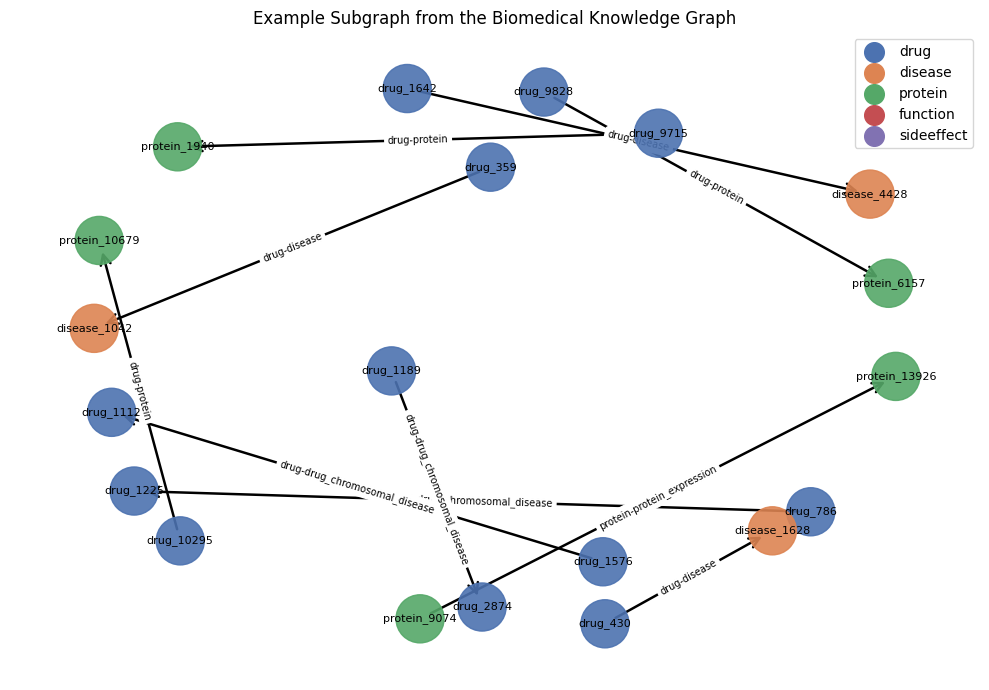

In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def draw_small_biokg_subgraph(graph, max_edges=10, seed=42):
    random.seed(seed)

    G = nx.DiGraph()

    edge_types = list(graph["edge_index_dict"].keys())
    sampled_edge_types = random.sample(edge_types, min(4, len(edge_types)))

    edge_count = 0

    for edge_type in sampled_edge_types:
        src_type, rel_type, dst_type = edge_type
        edge_index = graph["edge_index_dict"][edge_type]

        num_edges = edge_index.shape[1]
        sampled_edges = random.sample(range(num_edges), min(3, num_edges))

        for idx in sampled_edges:
            if edge_count >= max_edges:
                break

            src = int(edge_index[0, idx])
            dst = int(edge_index[1, idx])

            src_label = f"{src_type}_{src}"
            dst_label = f"{dst_type}_{dst}"

            G.add_node(src_label, node_type=src_type)
            G.add_node(dst_label, node_type=dst_type)

            G.add_edge(
                src_label,
                dst_label,
                relation=rel_type
            )

            edge_count += 1

    # Color map by node type
    color_map = {
        "drug": "#4C72B0",
        "disease": "#DD8452",
        "protein": "#55A868",
        "function": "#C44E52",
        "sideeffect": "#8172B2"
    }

    node_types = nx.get_node_attributes(G, "node_type")

    node_colors = [
        color_map.get(node_types[n], "gray")
        for n in G.nodes()
    ]

    pos = nx.spring_layout(G, seed=seed, k=1.5)

    plt.figure(figsize=(10, 7))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=1200,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="->",
        arrowsize=18,
        width=1.8
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    edge_labels = nx.get_edge_attributes(G, "relation")

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )

    # Legend
    for node_type, color in color_map.items():
        plt.scatter([], [], c=color, label=node_type, s=200)

    plt.legend(frameon=True)

    plt.title("Example Subgraph from the Biomedical Knowledge Graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_small_biokg_subgraph(graph)

## Initializing Node and Relation Embeddings

In this section, we define the embedding layer used for the heterogeneous biomedical graph.  

Each node type (such as drugs, diseases, and proteins) receives its own learnable embedding matrix, allowing the model to represent different biological entities in a shared latent space. In addition, a separate embedding matrix is created for relation types.  

These embeddings serve as the initial representations that will later be used by the attention and link prediction components of the model.

In [4]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_dim = 128

num_nodes_dict = graph["num_nodes_dict"]
node_types = list(num_nodes_dict.keys())

num_relations = 51

In [5]:
class MAGNNLiteEmbeddings(nn.Module):
    def __init__(self, num_nodes_dict, num_relations, embedding_dim):
        super().__init__()

        self.node_embeddings = nn.ModuleDict({
            node_type: nn.Embedding(num_nodes, embedding_dim)
            for node_type, num_nodes in num_nodes_dict.items()
        })

        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)

    def get_node_embedding(self, node_type, node_ids):
        return self.node_embeddings[node_type](node_ids)

    def get_relation_embedding(self, relation_ids):
        return self.relation_embeddings(relation_ids)

In [6]:
embedding_layer = MAGNNLiteEmbeddings(
    num_nodes_dict=num_nodes_dict,
    num_relations=num_relations,
    embedding_dim=embedding_dim
).to(device)

embedding_layer

MAGNNLiteEmbeddings(
  (node_embeddings): ModuleDict(
    (disease): Embedding(10687, 128)
    (drug): Embedding(10533, 128)
    (function): Embedding(45085, 128)
    (protein): Embedding(17499, 128)
    (sideeffect): Embedding(9969, 128)
  )
  (relation_embeddings): Embedding(51, 128)
)

## Constructing Valid Meta-Paths in the Biomedical Graph

In this section, we first build a table describing the relation types in the BioKG dataset, including the source and target node types associated with each relation ID.  

Using this information, we then construct all valid 2-hop meta-paths of the form:

A → B → C

where the destination node type of the first relation matches the source node type of the second relation. These meta-paths will later be used for message passing and attention-based aggregation in the model.

In [7]:
# Build a table of relation IDs and their source/target node types

import pandas as pd

rel_rows = []

for split_name, split in [("train", train_set), ("valid", valid_set), ("test", test_set)]:
    df = pd.DataFrame({
        "head_type": split["head_type"],
        "relation": split["relation"],
        "tail_type": split["tail_type"],
    })
    
    rel_rows.append(df.drop_duplicates())

relation_table = pd.concat(rel_rows).drop_duplicates().sort_values("relation")

relation_table.head(20)

,head_type,relation,tail_type
0,disease,0,protein
73547,drug,1,disease
78694,drug,2,drug
142124,drug,3,drug
160678,drug,4,drug
191026,drug,5,drug
239540,drug,6,drug
334382,drug,7,drug
334698,drug,8,drug
369358,drug,9,drug


In [8]:
# =========================
# Find valid 2-hop meta-paths
# r1: A -> B
# r2: B -> C
# therefore: A -> B -> C
# =========================

valid_metapaths = []

for _, r1 in relation_table.iterrows():
    for _, r2 in relation_table.iterrows():
        if r1["tail_type"] == r2["head_type"]:
            valid_metapaths.append({
                "start_type": r1["head_type"],
                "middle_type": r1["tail_type"],
                "end_type": r2["tail_type"],
                "relation_1": int(r1["relation"]),
                "relation_2": int(r2["relation"]),
                "metapath": f'{r1["head_type"]} --r{int(r1["relation"])}--> {r1["tail_type"]} --r{int(r2["relation"])}--> {r2["tail_type"]}'
            })

metapath_table = pd.DataFrame(valid_metapaths)

metapath_table.head(20)

,start_type,middle_type,end_type,relation_1,relation_2,metapath
0,disease,protein,function,0,43,disease --r0--> protein --r43--> function
1,disease,protein,protein,0,44,disease --r0--> protein --r44--> protein
2,disease,protein,protein,0,45,disease --r0--> protein --r45--> protein
3,disease,protein,protein,0,46,disease --r0--> protein --r46--> protein
4,disease,protein,protein,0,47,disease --r0--> protein --r47--> protein
5,disease,protein,protein,0,48,disease --r0--> protein --r48--> protein
6,disease,protein,protein,0,49,disease --r0--> protein --r49--> protein
7,disease,protein,protein,0,50,disease --r0--> protein --r50--> protein
8,drug,disease,protein,1,0,drug --r1--> disease --r0--> protein
9,drug,drug,disease,2,1,drug --r2--> drug --r1--> disease


## Organizing Training Edges by Relation Type

To efficiently sample neighbors and construct meta-path-based connections during training, we organize the training edges according to their relation type.  

This creates a dictionary that maps each relation ID to the corresponding set of edges in the biomedical graph.

In [9]:
from collections import defaultdict
import numpy as np

# =========================
# Build edge dictionaries by relation
# =========================

edges_by_relation = defaultdict(list)

for h_type, h, r, t_type, t in zip(
    train_set["head_type"],
    train_set["head"],
    train_set["relation"],
    train_set["tail_type"],
    train_set["tail"]
):
    edges_by_relation[int(r)].append((h_type, int(h), t_type, int(t)))

print("Number of relation types:", len(edges_by_relation))

Number of relation types: 51


## Building Relation-Based Neighbor Indices

To efficiently traverse the heterogeneous graph, we create an index structure that groups neighbors according to both the relation type and the source node.  

This allows fast lookup of valid neighboring nodes during meta-path construction and message passing.

In [10]:
# =========================
# Index edges by relation and source node
# =========================

relation_source_index = {}

for r, edges in edges_by_relation.items():
    source_dict = defaultdict(list)
    
    for h_type, h, t_type, t in edges:
        source_dict[(h_type, h)].append((t_type, t))
    
    relation_source_index[r] = source_dict

print("Index built successfully")

Index built successfully


## Selecting and Inspecting Frequent Meta-Paths

In this section, we analyze the valid 2-hop meta-paths and count how many actual instances each meta-path has in the training graph.  

We then map relation IDs to their biological relation names, sort the meta-paths by frequency, and select a subset of frequent meta-paths for the model. Finally, we sample example instances from one selected meta-path to verify that the constructed paths are valid.

In [11]:
def sample_2hop_metapath_instances(relation_1, relation_2, max_instances=20):
    """
    Finds examples of:
    node --relation_1--> middle --relation_2--> end
    """
    
    instances = []
    
    first_edges = edges_by_relation[relation_1]
    second_index = relation_source_index[relation_2]
    
    for h_type, h, mid_type, mid in first_edges:
        middle_key = (mid_type, mid)
        
        if middle_key in second_index:
            for end_type, end in second_index[middle_key]:
                instances.append({
                    "start_type": h_type,
                    "start": h,
                    "middle_type": mid_type,
                    "middle": mid,
                    "end_type": end_type,
                    "end": end,
                    "relation_1": relation_1,
                    "relation_2": relation_2
                })
                
                if len(instances) >= max_instances:
                    return instances
    
    return instances

In [12]:
import os
import pandas as pd

rel_map_path = os.path.join(
    dataset.root,
    "mapping",
    "relidx2relname.csv.gz"
)

rel_map_df = pd.read_csv(rel_map_path)

relation_id_to_name = dict(
    zip(
        rel_map_df["rel idx"],
        rel_map_df["rel name"]
    )
)

rel_map_df.head()

,rel idx,rel name
0,0,disease-protein
1,1,drug-disease
2,2,drug-drug_acquired_metabolic_disease
3,3,drug-drug_bacterial_infectious_disease
4,4,drug-drug_benign_neoplasm


In [46]:
def count_metapath_instances(row):
    r1 = row["relation_1"]
    r2 = row["relation_2"]

    edges1 = edges_by_relation.get(r1, [])
    edges2 = edges_by_relation.get(r2, [])

    # Count how many two-hop paths exist:
    # A --r1--> B --r2--> C

    tails_r1 = {}
    for src_type, src, dst_type, dst in edges1:
        key = (dst_type, dst)
        tails_r1[key] = tails_r1.get(key, 0) + 1

    heads_r2 = {}
    for src_type, src, dst_type, dst in edges2:
        key = (src_type, src)
        heads_r2[key] = heads_r2.get(key, 0) + 1

    count = 0
    for node, c1 in tails_r1.items():
        c2 = heads_r2.get(node, 0)
        count += c1 * c2

    return count
    
metapath_table["num_instances"] = metapath_table.apply(
    count_metapath_instances,
    axis=1
)

top_metapaths = (
    metapath_table
    .sort_values("num_instances", ascending=False)
    .reset_index(drop=True)
)

top_metapaths["relation_1_name"] = (
    top_metapaths["relation_1"]
    .map(relation_id_to_name)
)

top_metapaths["relation_2_name"] = (
    top_metapaths["relation_2"]
    .map(relation_id_to_name)
)

top_metapaths["pretty_metapath"] = (
    top_metapaths["start_type"]
    + " --"
    + top_metapaths["relation_1_name"]
    + "--> "
    + top_metapaths["middle_type"]
    + " --"
    + top_metapaths["relation_2_name"]
    + "--> "
    + top_metapaths["end_type"]
)

selected_metapaths = (
    top_metapaths
    .iloc[2:14]
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", None)
display(
    selected_metapaths[
        [
            "pretty_metapath",
            "num_instances"
        ]
    ]
)

,pretty_metapath,num_instances
0,protein --protein-protein_reaction--> protein --protein-protein_reaction--> protein,53562726
1,protein --protein-protein_catalysis--> protein --protein-protein_catalysis--> protein,46993308
2,protein --protein-protein_catalysis--> protein --protein-protein_reaction--> protein,46629684
3,protein --protein-protein_reaction--> protein --protein-protein_catalysis--> protein,46629684
4,protein --protein-protein_binding--> protein --protein-protein_binding--> protein,30854894
5,protein --protein-protein_binding--> protein --protein-protein_reaction--> protein,30604784
6,protein --protein-protein_reaction--> protein --protein-protein_binding--> protein,30604784
7,drug --drug-drug_cardiovascular_system_disease--> drug --drug-sideeffect--> sideeffect,27299014
8,protein --protein-protein_binding--> protein --protein-protein_catalysis--> protein,27109354
9,protein --protein-protein_catalysis--> protein --protein-protein_binding--> protein,27109354


In [14]:
mp = selected_metapaths.iloc[0]

instances = sample_2hop_metapath_instances(
    relation_1=int(mp["relation_1"]),
    relation_2=int(mp["relation_2"]),
    max_instances=10
)

pd.DataFrame(instances)

,start_type,start,middle_type,middle,end_type,end,relation_1,relation_2
0,protein,15036,protein,1227,protein,7311,50,50
1,protein,15036,protein,1227,protein,1178,50,50
2,protein,15036,protein,1227,protein,9412,50,50
3,protein,15036,protein,1227,protein,16671,50,50
4,protein,15036,protein,1227,protein,724,50,50
5,protein,15036,protein,1227,protein,3388,50,50
6,protein,15036,protein,1227,protein,16031,50,50
7,protein,15036,protein,1227,protein,4123,50,50
8,protein,15036,protein,1227,protein,6192,50,50
9,protein,15036,protein,1227,protein,1117,50,50


## Intra- and Inter-Meta-Path Attention

In this section, we implement the main attention components of the MAGNN-inspired model.  

First, the intra-meta-path attention layer encodes multiple instances of the same 2-hop meta-path by combining the embeddings of the start, middle, and end nodes. It then learns attention weights over these path instances and aggregates them into a single meta-path representation.  

Next, the inter-meta-path attention layer combines representations from multiple selected meta-paths. This allows the model to learn which biological relation patterns are more informative for the downstream link prediction task.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class IntraMetapathAttention(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        
        self.path_encoder = nn.Sequential(
            nn.Linear(3 * embedding_dim, embedding_dim),
            nn.Tanh()
        )
        
        self.attention = nn.Linear(embedding_dim, 1)

    def forward(self, start_emb, middle_emb, end_emb):
        # start_emb, middle_emb, end_emb: [num_instances, embedding_dim]
        
        path_input = torch.cat([start_emb, middle_emb, end_emb], dim=-1)
        
        path_emb = self.path_encoder(path_input)
        
        att_scores = self.attention(path_emb).squeeze(-1)
        att_weights = F.softmax(att_scores, dim=0)
        
        aggregated_emb = torch.sum(att_weights.unsqueeze(-1) * path_emb, dim=0)
        
        return aggregated_emb, att_weights

In [16]:
intra_attention = IntraMetapathAttention(embedding_dim=128).to(device)

instances_df = pd.DataFrame(instances)

start_type = instances_df["start_type"].iloc[0]
middle_type = instances_df["middle_type"].iloc[0]
end_type = instances_df["end_type"].iloc[0]

start_ids = torch.tensor(instances_df["start"].values, dtype=torch.long).to(device)
middle_ids = torch.tensor(instances_df["middle"].values, dtype=torch.long).to(device)
end_ids = torch.tensor(instances_df["end"].values, dtype=torch.long).to(device)

start_emb = embedding_layer.get_node_embedding(start_type, start_ids)
middle_emb = embedding_layer.get_node_embedding(middle_type, middle_ids)
end_emb = embedding_layer.get_node_embedding(end_type, end_ids)

aggregated_emb, att_weights = intra_attention(start_emb, middle_emb, end_emb)

print("Aggregated embedding shape:", aggregated_emb.shape)
print("Attention weights shape:", att_weights.shape)
print("Attention weights:", att_weights.detach().cpu().numpy())

Aggregated embedding shape: torch.Size([128])
Attention weights shape: torch.Size([10])
Attention weights: [0.09887688 0.09006895 0.08742829 0.10261466 0.09338557 0.11900344
 0.08759385 0.10145506 0.11210318 0.10747007]


In [17]:
class InterMetapathAttention(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        
        self.attention = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.Tanh(),
            nn.Linear(embedding_dim, 1)
        )

    def forward(self, metapath_embs):
        # metapath_embs: [num_metapaths, embedding_dim]
        
        scores = self.attention(metapath_embs).squeeze(-1)
        weights = F.softmax(scores, dim=0)
        
        final_emb = torch.sum(weights.unsqueeze(-1) * metapath_embs, dim=0)
        
        return final_emb, weights

In [18]:
inter_attention = InterMetapathAttention(embedding_dim=128).to(device)

metapath_embs = torch.stack([
    aggregated_emb,
    aggregated_emb,
    aggregated_emb
], dim=0)

final_emb, inter_weights = inter_attention(metapath_embs)

print("Final embedding shape:", final_emb.shape)
print("Inter-metapath weights:", inter_weights.detach().cpu().numpy())

Final embedding shape: torch.Size([128])
Inter-metapath weights: [0.33333334 0.33333334 0.33333334]


In [19]:
def encode_metapaths_for_selected_node(
    selected_metapaths,
    max_instances_per_metapath=20
):
    metapath_embeddings = []
    metapath_names = []

    for _, mp in selected_metapaths.iterrows():
        relation_1 = int(mp["relation_1"])
        relation_2 = int(mp["relation_2"])

        instances = sample_2hop_metapath_instances(
            relation_1=relation_1,
            relation_2=relation_2,
            max_instances=max_instances_per_metapath
        )

        if len(instances) == 0:
            continue

        instances_df = pd.DataFrame(instances)

        start_type = instances_df["start_type"].iloc[0]
        middle_type = instances_df["middle_type"].iloc[0]
        end_type = instances_df["end_type"].iloc[0]

        start_ids = torch.tensor(instances_df["start"].values, dtype=torch.long).to(device)
        middle_ids = torch.tensor(instances_df["middle"].values, dtype=torch.long).to(device)
        end_ids = torch.tensor(instances_df["end"].values, dtype=torch.long).to(device)

        start_emb = embedding_layer.get_node_embedding(start_type, start_ids)
        middle_emb = embedding_layer.get_node_embedding(middle_type, middle_ids)
        end_emb = embedding_layer.get_node_embedding(end_type, end_ids)

        aggregated_emb, intra_weights = intra_attention(
            start_emb,
            middle_emb,
            end_emb
        )

        metapath_embeddings.append(aggregated_emb)
        metapath_names.append(mp["metapath"])

    metapath_embeddings = torch.stack(metapath_embeddings, dim=0)

    final_emb, inter_weights = inter_attention(metapath_embeddings)

    return final_emb, inter_weights, metapath_names

In [20]:
final_emb, inter_weights, metapath_names = encode_metapaths_for_selected_node(
    selected_metapaths,
    max_instances_per_metapath=20
)

print("Final embedding shape:", final_emb.shape)

for name, weight in zip(metapath_names, inter_weights.detach().cpu().numpy()):
    print(f"{weight:.4f} | {name}")

Final embedding shape: torch.Size([128])
0.0836 | protein --r50--> protein --r50--> protein
0.0803 | protein --r46--> protein --r46--> protein
0.0846 | protein --r46--> protein --r50--> protein
0.0775 | protein --r50--> protein --r46--> protein
0.0817 | protein --r45--> protein --r45--> protein
0.0677 | protein --r45--> protein --r50--> protein
0.0844 | protein --r50--> protein --r45--> protein
0.1016 | drug --r6--> drug --r41--> sideeffect
0.0693 | protein --r45--> protein --r46--> protein
0.0832 | protein --r46--> protein --r45--> protein
0.0853 | drug --r13--> drug --r41--> sideeffect
0.1008 | drug --r6--> drug --r6--> drug


## Link Prediction Head

In this section, we implement the final link prediction module used to score candidate edges in the biomedical knowledge graph.  

The model receives the embeddings of the head node, relation type, and tail node, concatenates them into a single feature vector, and passes the result through a small multilayer perceptron (MLP). The output is a scalar score representing the likelihood that the corresponding biological relation exists in the graph.

Finally, we test the prediction head on a sample edge from the training set.

In [21]:
class LinkPredictionHead(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(3 * embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, 1)
        )

    def forward(self, head_emb, relation_emb, tail_emb):
        x = torch.cat([head_emb, relation_emb, tail_emb], dim=-1)
        score = self.mlp(x).squeeze(-1)
        return score

In [22]:
link_predictor = LinkPredictionHead(embedding_dim=128).to(device)

In [23]:
i = 0

h_type = train_set["head_type"][i]
h_id = torch.tensor([train_set["head"][i]], dtype=torch.long).to(device)

r_id = torch.tensor([train_set["relation"][i]], dtype=torch.long).to(device)

t_type = train_set["tail_type"][i]
t_id = torch.tensor([train_set["tail"][i]], dtype=torch.long).to(device)

head_emb = embedding_layer.get_node_embedding(h_type, h_id).squeeze(0)
relation_emb = embedding_layer.get_relation_embedding(r_id).squeeze(0)
tail_emb = embedding_layer.get_node_embedding(t_type, t_id).squeeze(0)

score = link_predictor(head_emb, relation_emb, tail_emb)

print("Score:", score.item())

Score: -0.2737064063549042


In [24]:
import random

def sample_negative_tail(tail_type, batch_size=1):
    """
    Sample random tail nodes from the same tail type.
    """
    num_nodes = num_nodes_dict[tail_type]
    
    negative_tail_ids = torch.randint(
        low=0,
        high=num_nodes,
        size=(batch_size,),
        dtype=torch.long,
        device=device
    )
    
    return negative_tail_ids

In [25]:
i = 0

t_type = train_set["tail_type"][i]

negative_tail = sample_negative_tail(t_type, batch_size=5)

print("Tail type:", t_type)
print("Negative tails:", negative_tail)

Tail type: protein
Negative tails: tensor([  339, 15675,  4527, 14090, 10531])


In [26]:
def score_positive_and_negative(i):
    h_type = train_set["head_type"][i]
    h_id = torch.tensor([train_set["head"][i]], dtype=torch.long).to(device)

    r_id = torch.tensor([train_set["relation"][i]], dtype=torch.long).to(device)

    t_type = train_set["tail_type"][i]
    t_id = torch.tensor([train_set["tail"][i]], dtype=torch.long).to(device)

    # Positive triplet
    head_emb = embedding_layer.get_node_embedding(h_type, h_id).squeeze(0)
    relation_emb = embedding_layer.get_relation_embedding(r_id).squeeze(0)
    tail_emb = embedding_layer.get_node_embedding(t_type, t_id).squeeze(0)

    positive_score = link_predictor(head_emb, relation_emb, tail_emb)

    # Negative triplet
    neg_t_id = sample_negative_tail(t_type, batch_size=1)

    neg_tail_emb = embedding_layer.get_node_embedding(t_type, neg_t_id).squeeze(0)

    negative_score = link_predictor(head_emb, relation_emb, neg_tail_emb)

    return positive_score, negative_score

In [27]:
pos_score, neg_score = score_positive_and_negative(0)

print("Positive score:", pos_score.item())
print("Negative score:", neg_score.item())

Positive score: -0.2737064063549042
Negative score: -0.417926162481308


In [28]:
margin = 1.0

def ranking_loss(pos_score, neg_score, margin=1.0):
    return torch.relu(margin - pos_score + neg_score)

loss = ranking_loss(pos_score, neg_score, margin=1.0)

print("Loss:", loss.item())

Loss: 0.8557802438735962


## Training, Evaluation, and Hyperparameter Comparison

In this section, we define the full training and evaluation pipeline for the link prediction model.  

First, we create a function that initializes a fresh model and optimizer for each experiment. This is important for a fair comparison between hyperparameter settings, since every experiment starts from the same random initialization instead of continuing from a previously trained model.

We then define the scoring function for positive and negative triplets, where negative examples are created by corrupting the tail node. The model is trained using a margin-based ranking loss, which encourages true biological relations to receive higher scores than corrupted relations.

Finally, we evaluate the model using several link prediction metrics, including ROC-AUC, accuracy, precision, recall, and F1 score. Multiple training configurations are compared, and the best model is selected according to validation ROC-AUC.

In [39]:
def initialize_model(seed=42, lr=3e-4):
    """
    Create a completely fresh model and optimizer.
    This is important for fair hyperparameter comparison: every experiment must
    start from a new random initialization, not from the previous experiment.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    embedding_layer = MAGNNLiteEmbeddings(
        num_nodes_dict=num_nodes_dict,
        num_relations=num_relations,
        embedding_dim=embedding_dim
    ).to(device)

    intra_attention = IntraMetapathAttention(embedding_dim=embedding_dim).to(device)
    inter_attention = InterMetapathAttention(embedding_dim=embedding_dim).to(device)
    link_predictor = LinkPredictionHead(embedding_dim=embedding_dim).to(device)

    optimizer = torch.optim.Adam(
        list(embedding_layer.parameters()) +
        list(intra_attention.parameters()) +
        list(inter_attention.parameters()) +
        list(link_predictor.parameters()),
        lr=lr
    )

    return embedding_layer, intra_attention, inter_attention, link_predictor, optimizer


# Initial model, useful for single-cell tests before running experiments.
SEED = 42
embedding_layer, intra_attention, inter_attention, link_predictor, optimizer = initialize_model(seed=SEED)


def set_train_mode():
    embedding_layer.train()
    intra_attention.train()
    inter_attention.train()
    link_predictor.train()


def set_eval_mode():
    embedding_layer.eval()
    intra_attention.eval()
    inter_attention.eval()
    link_predictor.eval()


def score_batch(split, indices, negative=False, metapath_emb=None, return_tail_ids=False):
    """
    Score a batch of positive or randomly corrupted triplets.

    If negative=True, the tail node is randomly replaced by a node from the same
    tail type. When return_tail_ids=True, the function also returns the actual
    sampled negative tail IDs, so visualizations can display the real negative examples.
    """
    scores = []
    used_tail_ids = []

    # Compute the meta-path embedding once and reuse it for this batch.
    if metapath_emb is None:
        metapath_emb, _, _ = encode_metapaths_for_selected_node(
            selected_metapaths,
            max_instances_per_metapath=20
        )

    for i in indices:
        h_type = split["head_type"][i]
        h_id = torch.tensor([split["head"][i]], dtype=torch.long).to(device)

        r_id = torch.tensor([split["relation"][i]], dtype=torch.long).to(device)

        t_type = split["tail_type"][i]

        if negative:
            t_id = sample_negative_tail(t_type, batch_size=1)
        else:
            t_id = torch.tensor([split["tail"][i]], dtype=torch.long).to(device)

        head_emb = embedding_layer.get_node_embedding(h_type, h_id).squeeze(0)
        relation_emb = embedding_layer.get_relation_embedding(r_id).squeeze(0)
        tail_emb = embedding_layer.get_node_embedding(t_type, t_id).squeeze(0)

        # Current project design: inject a global meta-path representation into the head embedding.
        # Note: this is not node-specific yet; we discuss this limitation in the report.
        head_emb = head_emb + metapath_emb

        score = link_predictor(head_emb, relation_emb, tail_emb)
        scores.append(score)

        if negative:
            used_tail_ids.append(int(t_id.item()))

    scores = torch.stack(scores)

    if negative and return_tail_ids:
        return scores, used_tail_ids

    return scores


def train_model_batch(num_epochs=10, steps_per_epoch=300, batch_size=128, margin=1.0):
    loss_history = []

    for epoch in range(num_epochs):
        set_train_mode()
        total_loss = 0.0

        for step in range(steps_per_epoch):
            indices = [
                random.randint(0, len(train_set["head"]) - 1)
                for _ in range(batch_size)
            ]

            # Reuse the same meta-path embedding for positive and negative scores in this step.
            metapath_emb, _, _ = encode_metapaths_for_selected_node(
                selected_metapaths,
                max_instances_per_metapath=20
            )

            pos_scores = score_batch(train_set, indices, negative=False, metapath_emb=metapath_emb)
            neg_scores = score_batch(train_set, indices, negative=True, metapath_emb=metapath_emb)

            loss = torch.relu(margin - pos_scores + neg_scores).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        loss_history.append(avg_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

    return loss_history

In [40]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

@torch.no_grad()
def evaluate_link_prediction(split, num_samples=1000, threshold=0.0):
    embedding_layer.eval()
    intra_attention.eval()
    inter_attention.eval()
    link_predictor.eval()

    n = len(split["head"])
    indices = random.sample(range(n), min(num_samples, n))

    pos_scores = score_batch(split, indices, negative=False)
    neg_scores = score_batch(split, indices, negative=True)

    scores = torch.cat([pos_scores, neg_scores]).detach().cpu().numpy()
    labels = np.array([1] * len(pos_scores) + [0] * len(neg_scores))

    auc = roc_auc_score(labels, scores)

    # Convert scores to binary predictions
    preds = (scores > threshold).astype(int)

    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "ROC-AUC": auc,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }

Running experiment: small
{'name': 'small', 'num_epochs': 5, 'steps_per_epoch': 100, 'batch_size': 32, 'margin': 1.0, 'lr': 0.0003}
Epoch 1/5 | Loss: 0.9858
Epoch 2/5 | Loss: 0.9618
Epoch 3/5 | Loss: 0.9400
Epoch 4/5 | Loss: 0.9015
Epoch 5/5 | Loss: 0.8864


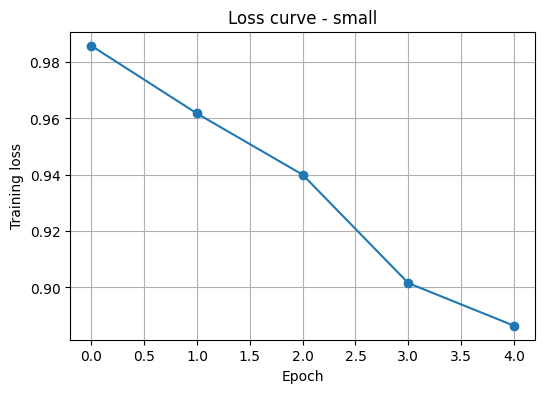

Running experiment: base
{'name': 'base', 'num_epochs': 10, 'steps_per_epoch': 200, 'batch_size': 64, 'margin': 1.0, 'lr': 0.0003}
Epoch 1/10 | Loss: 0.9616
Epoch 2/10 | Loss: 0.8880
Epoch 3/10 | Loss: 0.8572
Epoch 4/10 | Loss: 0.8071
Epoch 5/10 | Loss: 0.7734
Epoch 6/10 | Loss: 0.7459
Epoch 7/10 | Loss: 0.7222
Epoch 8/10 | Loss: 0.7010
Epoch 9/10 | Loss: 0.6807
Epoch 10/10 | Loss: 0.6520


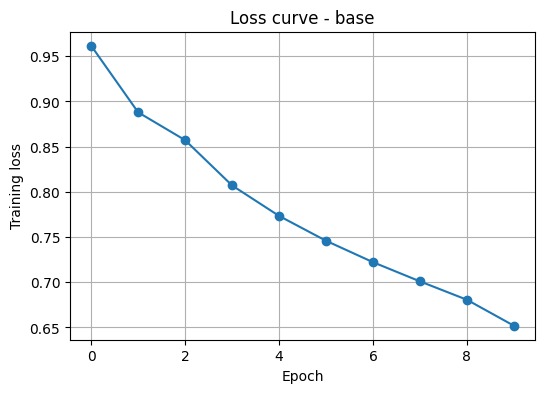

Running experiment: longer
{'name': 'longer', 'num_epochs': 15, 'steps_per_epoch': 200, 'batch_size': 64, 'margin': 1.0, 'lr': 0.0003}
Epoch 1/15 | Loss: 0.9616
Epoch 2/15 | Loss: 0.8880
Epoch 3/15 | Loss: 0.8572
Epoch 4/15 | Loss: 0.8071
Epoch 5/15 | Loss: 0.7734
Epoch 6/15 | Loss: 0.7459
Epoch 7/15 | Loss: 0.7222
Epoch 8/15 | Loss: 0.7010
Epoch 9/15 | Loss: 0.6807
Epoch 10/15 | Loss: 0.6520
Epoch 11/15 | Loss: 0.6281
Epoch 12/15 | Loss: 0.6388
Epoch 13/15 | Loss: 0.6121
Epoch 14/15 | Loss: 0.6045
Epoch 15/15 | Loss: 0.5975


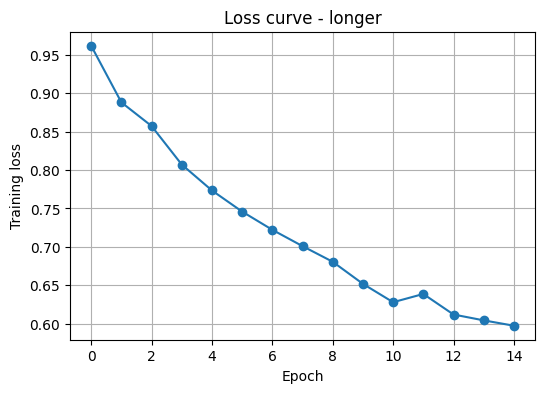

Running experiment: large_batch
{'name': 'large_batch', 'num_epochs': 10, 'steps_per_epoch': 200, 'batch_size': 128, 'margin': 1.0, 'lr': 0.0003}
Epoch 1/10 | Loss: 0.9436
Epoch 2/10 | Loss: 0.8637
Epoch 3/10 | Loss: 0.8032
Epoch 4/10 | Loss: 0.7589
Epoch 5/10 | Loss: 0.7168
Epoch 6/10 | Loss: 0.6824
Epoch 7/10 | Loss: 0.6556
Epoch 8/10 | Loss: 0.6329
Epoch 9/10 | Loss: 0.6107
Epoch 10/10 | Loss: 0.5900


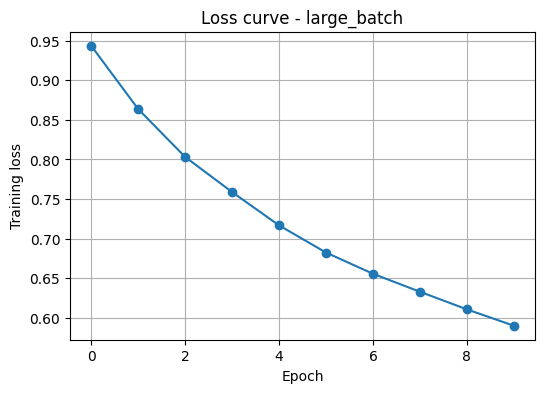

Best experiment: large_batch | validation ROC-AUC: 0.705441


,experiment,num_epochs,steps_per_epoch,batch_size,margin,lr,ROC-AUC,Accuracy,Precision,Recall,F1
3,large_batch,10,200,128,1.0,0.0003,0.705441,0.5895,0.559390,0.843,0.672517
2,longer,15,200,64,1.0,0.0003,0.687988,0.5800,0.553763,0.824,0.662379
1,base,10,200,64,1.0,0.0003,0.665441,0.5855,0.560339,0.794,0.657013
0,small,5,100,32,1.0,0.0003,0.577055,0.5175,0.509695,0.920,0.655971


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

experiment_configs = [
    {
        "name": "small",
        "num_epochs": 5,
        "steps_per_epoch": 100,
        "batch_size": 32,
        "margin": 1.0,
        "lr": 3e-4,
    },
    {
        "name": "base",
        "num_epochs": 10,
        "steps_per_epoch": 200,
        "batch_size": 64,
        "margin": 1.0,
        "lr": 3e-4,
    },
    {
        "name": "longer",
        "num_epochs": 15,
        "steps_per_epoch": 200,
        "batch_size": 64,
        "margin": 1.0,
        "lr": 3e-4,
    },
    {
        "name": "large_batch",
        "num_epochs": 10,
        "steps_per_epoch": 200,
        "batch_size": 128,
        "margin": 1.0,
        "lr": 3e-4,
    },
]

all_results = []
loss_histories = {}
best_auc = -1
best_state = None
best_experiment = None

for exp_id, config in enumerate(experiment_configs):
    print("=" * 80)
    print(f"Running experiment: {config['name']}")
    print(config)

    # Critical fix: start each experiment from a fresh model and optimizer.
    embedding_layer, intra_attention, inter_attention, link_predictor, optimizer = initialize_model(
        seed=SEED,
        lr=config["lr"]
    )

    loss_history = train_model_batch(
        num_epochs=config["num_epochs"],
        steps_per_epoch=config["steps_per_epoch"],
        batch_size=config["batch_size"],
        margin=config["margin"],
    )

    loss_histories[config["name"]] = loss_history

    plt.figure(figsize=(6, 4))
    plt.plot(loss_history, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss curve - {config['name']}")
    plt.grid(True)
    plt.show()

    valid_metrics = evaluate_link_prediction(
        valid_set,
        num_samples=1000
    )

    row = {
        "experiment": config["name"],
        "num_epochs": config["num_epochs"],
        "steps_per_epoch": config["steps_per_epoch"],
        "batch_size": config["batch_size"],
        "margin": config["margin"],
        "lr": config["lr"],
    }

    row.update(valid_metrics)
    all_results.append(row)

    if valid_metrics["ROC-AUC"] > best_auc:
        best_auc = valid_metrics["ROC-AUC"]
        best_experiment = config["name"]
        best_state = {
            "embedding_layer": embedding_layer.state_dict(),
            "intra_attention": intra_attention.state_dict(),
            "inter_attention": inter_attention.state_dict(),
            "link_predictor": link_predictor.state_dict(),
        }

results_df = pd.DataFrame(all_results)

print("Best experiment:", best_experiment, "| validation ROC-AUC:", best_auc)

display(
    results_df.sort_values("ROC-AUC", ascending=False)
)


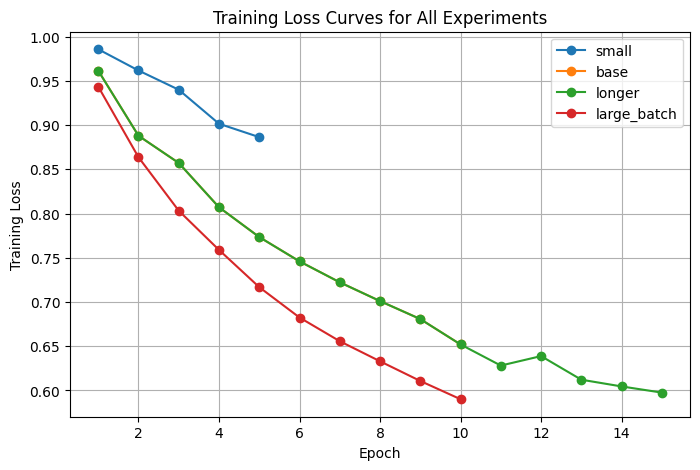

In [47]:
plt.figure(figsize=(8, 5))

for exp_name, loss_history in loss_histories.items():
    epochs = range(1, len(loss_history) + 1)

    plt.plot(
        epochs,
        loss_history,
        marker="o",
        label=exp_name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves for All Experiments")

plt.legend()
plt.grid(True)

plt.show()

In [48]:
for name, history in loss_histories.items():
    print(name)
    print(history)
    print()

small
[0.9858168578147888, 0.9617582046985627, 0.9400213694572449, 0.901539301276207, 0.8864104551076889]

base
[0.9616384249925614, 0.8879954463243485, 0.8572125178575516, 0.8071039873361587, 0.7734105515480042, 0.7459226441383362, 0.7222350241243839, 0.7010131232440472, 0.6806700825691223, 0.6519601181149483]

longer
[0.9616384249925614, 0.8879954463243485, 0.8572125178575516, 0.8071039873361587, 0.7734105515480042, 0.7459226441383362, 0.7222350241243839, 0.7010131232440472, 0.6806700825691223, 0.6519601181149483, 0.6280787293612957, 0.6387969227135182, 0.6120955738425254, 0.6044843007624149, 0.5975120933353901]

large_batch
[0.943618391752243, 0.8637014040350914, 0.8032161301374435, 0.7588671529293061, 0.7167534852027893, 0.6824106785655022, 0.6556292942166329, 0.6329245784878731, 0.6106590436398983, 0.5900210992991924]



In [50]:
embedding_layer.load_state_dict(best_state["embedding_layer"])
intra_attention.load_state_dict(best_state["intra_attention"])
inter_attention.load_state_dict(best_state["inter_attention"])
link_predictor.load_state_dict(best_state["link_predictor"])

<All keys matched successfully>

In [51]:
test_metrics = evaluate_link_prediction(
    test_set,
    num_samples=1000
)

print("Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Metrics:
ROC-AUC: 0.7114
Accuracy: 0.6080
Precision: 0.5745
Recall: 0.8330
F1: 0.6800


## Collecting Prediction Examples for Model Analysis

In this section, we evaluate the trained model on randomly sampled validation edges and collect both positive and negative prediction examples.  

For each sampled edge, we compute the prediction score assigned by the model. Negative examples are generated by randomly replacing the tail node while keeping the relation type unchanged.  

The collected examples are then organized into a table that stores the edge information, true labels, and prediction scores.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch

@torch.no_grad()
def collect_prediction_examples(split, num_samples=1000):
    embedding_layer.eval()
    intra_attention.eval()
    inter_attention.eval()
    link_predictor.eval()

    n = len(split["head"])
    indices = random.sample(range(n), min(num_samples, n))

    pos_scores = score_batch(split, indices, negative=False).detach().cpu()

    neg_scores, neg_tail_ids = score_batch(
        split,
        indices,
        negative=True,
        return_tail_ids=True
    )
    neg_scores = neg_scores.detach().cpu()

    rows = []

    for i, idx in enumerate(indices):
        rows.append({
            "example_type": "positive_edge",
            "head_type": split["head_type"][idx],
            "head": int(split["head"][idx]),
            "relation": int(split["relation"][idx]),
            "tail_type": split["tail_type"][idx],
            "tail": int(split["tail"][idx]),
            "true_label": 1,
            "label": 1,
            "score": float(pos_scores[i])
        })

        rows.append({
            "example_type": "negative_edge",
            "head_type": split["head_type"][idx],
            "head": int(split["head"][idx]),
            "relation": int(split["relation"][idx]),
            "tail_type": split["tail_type"][idx],
            "tail": int(neg_tail_ids[i]),
            "true_label": 0,
            "label": 0,
            "score": float(neg_scores[i])
        })

    return pd.DataFrame(rows)

In [38]:
examples_df = collect_prediction_examples(valid_set, num_samples=1000)
examples_df.head()

,example_type,head_type,head,relation,tail_type,tail,true_label,label,score
0,positive_edge,function,10690,42,function,27539,1,1,0.720226
1,negative_edge,function,10690,42,function,23484,0,0,0.453928
2,positive_edge,protein,5226,46,protein,2848,1,1,0.026508
3,negative_edge,protein,5226,46,protein,3553,0,0,0.344067
4,positive_edge,protein,12631,46,protein,16769,1,1,0.002877


In [140]:
best_positive = examples_df[examples_df["true_label"] == 1].sort_values("score", ascending=False).head(10)
bad_positive = examples_df[examples_df["true_label"] == 1].sort_values("score", ascending=True).head(10)

best_negative = examples_df[examples_df["true_label"] == 0].sort_values("score", ascending=True).head(10)
bad_negative = examples_df[examples_df["true_label"] == 0].sort_values("score", ascending=False).head(10)

print("Good positive predictions:")
display(best_positive)

print("Bad positive predictions / false negatives:")
display(bad_positive)

print("Good negative predictions:")
display(best_negative)

print("Bad negative predictions / false positives:")
display(bad_negative)

Good positive predictions:


,example_type,head_type,head,relation,tail_type,tail,true_label,label,score
1660,positive_edge,function,30208,42,function,31761,1,1,1.333594
1872,positive_edge,function,22376,42,function,7780,1,1,1.241424
202,positive_edge,drug,565,13,drug,940,1,1,1.235344
1128,positive_edge,drug,1201,6,drug,1225,1,1,1.127524
1842,positive_edge,function,38346,42,function,14763,1,1,1.099562
690,positive_edge,function,38233,42,function,22617,1,1,1.088769
1476,positive_edge,protein,5367,43,function,21580,1,1,1.056436
1412,positive_edge,function,45010,42,function,7763,1,1,1.038644
624,positive_edge,drug,106,17,drug,1119,1,1,1.028172
1208,positive_edge,protein,10882,43,function,16299,1,1,0.975830


Bad positive predictions / false negatives:


,example_type,head_type,head,relation,tail_type,tail,true_label,label,score
230,positive_edge,drug,502,41,sideeffect,3001,1,1,-1.939327
1254,positive_edge,drug,6997,41,sideeffect,6376,1,1,-1.832213
520,positive_edge,protein,1817,43,function,27795,1,1,-1.796846
1292,positive_edge,drug,1441,13,drug,3497,1,1,-1.733258
1490,positive_edge,function,38212,42,function,19213,1,1,-1.684863
110,positive_edge,function,6146,42,function,39289,1,1,-1.657703
1070,positive_edge,drug,762,13,drug,3497,1,1,-1.618240
704,positive_edge,protein,1221,43,function,8415,1,1,-1.607427
1306,positive_edge,drug,496,41,sideeffect,5893,1,1,-1.600677
492,positive_edge,drug,1396,41,sideeffect,8622,1,1,-1.508783


Good negative predictions:


,example_type,head_type,head,relation,tail_type,tail,true_label,label,score
117,negative_edge,protein,1284,46,protein,2644,0,0,-1.756209
1143,negative_edge,protein,8614,43,function,2097,0,0,-1.739880
1447,negative_edge,protein,10792,43,function,24095,0,0,-1.737043
307,negative_edge,protein,1010,43,function,6146,0,0,-1.711582
233,negative_edge,protein,3524,43,function,26611,0,0,-1.627904
1041,negative_edge,protein,16589,46,protein,3768,0,0,-1.619937
155,negative_edge,drug,898,41,sideeffect,176,0,0,-1.594828
493,negative_edge,drug,1396,41,sideeffect,8622,0,0,-1.539969
1925,negative_edge,drug,1418,41,sideeffect,9098,0,0,-1.519898
1431,negative_edge,protein,7247,43,function,1232,0,0,-1.493283


Bad negative predictions / false positives:


,example_type,head_type,head,relation,tail_type,tail,true_label,label,score
639,negative_edge,protein,10020,45,protein,9686,0,0,1.574300
1363,negative_edge,function,26615,42,function,34060,0,0,1.279031
1305,negative_edge,protein,1801,43,function,32398,0,0,1.266090
1779,negative_edge,function,21757,42,function,10684,0,0,1.205213
1289,negative_edge,drug,1225,22,drug,1319,0,0,1.175159
1993,negative_edge,function,14834,42,function,15936,0,0,1.169876
1433,negative_edge,protein,9132,43,function,22424,0,0,1.142170
1935,negative_edge,drug,527,17,drug,6070,0,0,1.102079
461,negative_edge,function,22776,42,function,40292,0,0,1.091776
33,negative_edge,function,25011,42,function,33589,0,0,1.022682


## Identifying Good and Bad Predictions

To better understand the model’s behavior, we analyze examples with extremely high and low prediction scores.  

We separately examine:
- correctly predicted positive edges,
- incorrectly predicted positive edges (false negatives),
- correctly predicted negative edges,
- and incorrectly predicted negative edges (false positives).

Finally, we select representative examples from each category for graph visualization and qualitative analysis.

In [141]:
good_positive = examples_df[examples_df["label"] == 1].sort_values("score", ascending=False).iloc[0]
bad_positive = examples_df[examples_df["label"] == 1].sort_values("score", ascending=True).iloc[0]
good_negative = examples_df[examples_df["label"] == 0].sort_values("score", ascending=True).iloc[0]
bad_negative = examples_df[examples_df["label"] == 0].sort_values("score", ascending=False).iloc[0]

In [114]:
import networkx as nx
import matplotlib.pyplot as plt

def node_name(node_type, node_id):
    return f"{node_type}:{node_id}"

def build_local_subgraph(example, max_neighbors=10):
    G = nx.DiGraph()

    h_type = example["head_type"]
    h = int(example["head"])
    r = int(example["relation"])
    t_type = example["tail_type"]
    t = int(example["tail"])

    h_node = node_name(h_type, h)
    t_node = node_name(t_type, t)

    G.add_node(h_node, node_type=h_type)
    G.add_node(t_node, node_type=t_type)

    G.add_edge(
        h_node,
        t_node,
        relation=relation_id_to_name.get(r, f"r{r}"),
        target_edge=True,
        score=float(example["score"]),
        label=int(example["label"])
    )

    added = 0

    for rel, edges in edges_by_relation.items():
        for src_type, src, dst_type, dst in edges:
            if added >= max_neighbors:
                break

            if (src_type == h_type and src == h) or (dst_type == h_type and dst == h) or \
               (src_type == t_type and src == t) or (dst_type == t_type and dst == t):

                src_node = node_name(src_type, src)
                dst_node = node_name(dst_type, dst)

                G.add_node(src_node, node_type=src_type)
                G.add_node(dst_node, node_type=dst_type)

                G.add_edge(
                    src_node,
                    dst_node,
                    relation=relation_id_to_name.get(rel, f"r{rel}"),
                    target_edge=False
                )

                added += 1

    return G

In [1]:
def draw_prediction_subgraph(example, title="", max_neighbors=10):
    G = build_local_subgraph(example, max_neighbors=max_neighbors)

    h_node = node_name(example["head_type"], int(example["head"]))
    t_node = node_name(example["tail_type"], int(example["tail"]))
    
    # Force the target edge to be marked correctly, even if it was overwritten
    if G.has_edge(h_node, t_node):
        G[h_node][t_node]["target_edge"] = True
        G[h_node][t_node]["relation"] = relation_id_to_name.get(
            int(example["relation"]),
            str(example["relation"])
        )
    else:
        G.add_edge(
            h_node,
            t_node,
            target_edge=True,
            relation=relation_id_to_name.get(
                int(example["relation"]),
                str(example["relation"])
            )
        )
    pos = {}

    # Put the predicted edge clearly on the right
    pos[h_node] = [0.5, 0.95]
    pos[t_node] = [0.5, -0.95]

    # Put all other neighbors on a left semicircle
    other_nodes = [
        node for node in G.nodes()
        if node not in [h_node, t_node]
    ]

    if len(other_nodes) > 0:
        radius = 1.4
        angles = np.linspace(np.pi / 2, 3 * np.pi / 2, len(other_nodes))

        for node, angle in zip(other_nodes, angles):
            pos[node] = [
                -0.8 + radius * np.cos(angle),
                radius * np.sin(angle)
            ]

    node_colors = []
    for node in G.nodes():
        node_type = G.nodes[node].get("node_type", "")

        if node_type == "drug":
            node_colors.append("lightblue")
        elif node_type == "disease":
            node_colors.append("lightcoral")
        elif node_type == "protein":
            node_colors.append("lightgreen")
        elif node_type == "function":
            node_colors.append("khaki")
        elif node_type == "sideeffect":
            node_colors.append("plum")
        else:
            node_colors.append("lightgray")

    target_edges = []
    other_edges = []

    for u, v, data in G.edges(data=True):
        if data.get("target_edge", False):
            target_edges.append((u, v))
        else:
            other_edges.append((u, v))

    plt.figure(figsize=(12, 8))

    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=1000,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=other_edges,
        edge_color="lightgray",
        width=1.5,
        arrows=True,
        arrowsize=16
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=target_edges,
        edge_color="green" if int(example["label"]) == 1 else "red",
        width=5,
        arrows=True,
        arrowsize=24
    )

    nx.draw_networkx_labels(
        G, pos,
        font_size=8
    )

    # Show labels only for the predicted edge to avoid clutter
    edge_labels = {
        (u, v): data["relation"]
        for u, v, data in G.edges(data=True)
        if data.get("target_edge", False)
    }

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=9,
        label_pos=0.5
    )

    plt.title(
        f"{title}\n"
        f"label={int(example['label'])}, score={float(example['score']):.3f}"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [2]:
import pandas as pd
import os

rel_map_path = os.path.join(
    dataset.root,
    "mapping",
    "relidx2relname.csv.gz"
)

rel_map_df = pd.read_csv(rel_map_path)

relation_id_to_name = dict(
    zip(
        rel_map_df["rel idx"],
        rel_map_df["rel name"]
    )
)

NameError: name 'dataset' is not defined

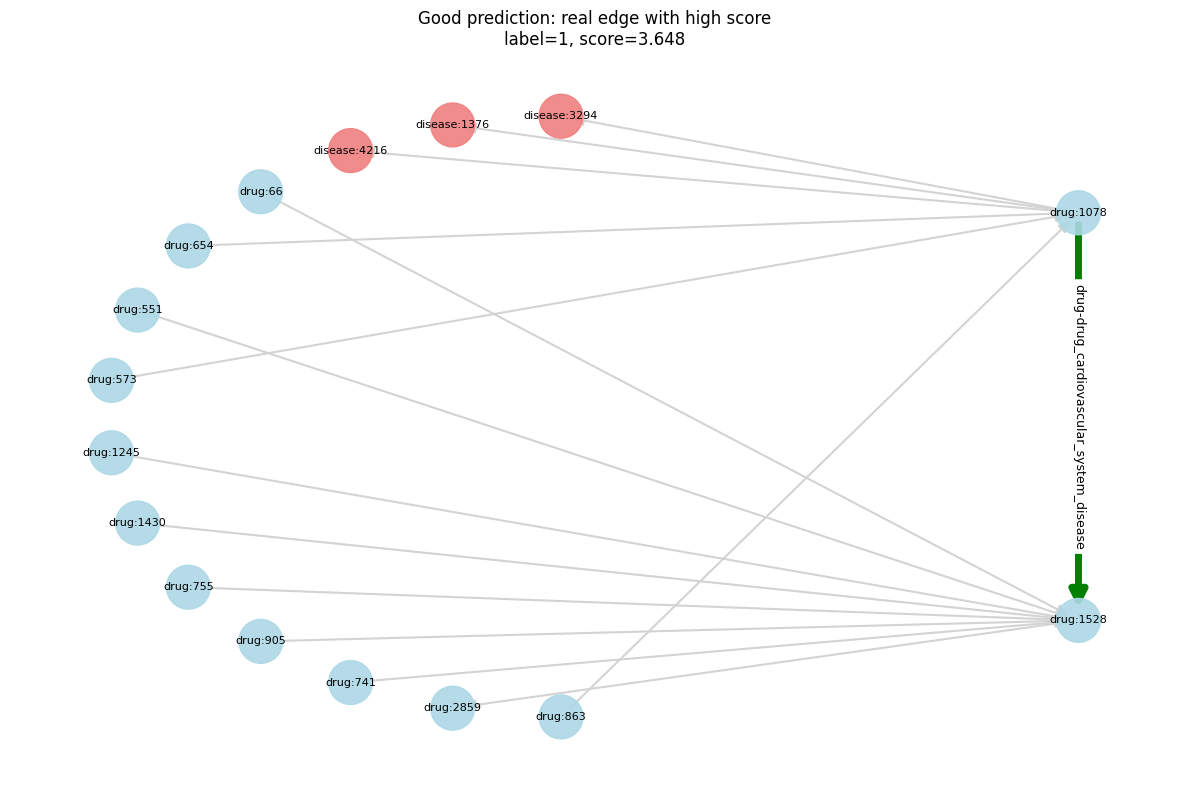

In [117]:
draw_prediction_subgraph(
    good_positive,
    title="Good prediction: real edge with high score",
    max_neighbors=15
)

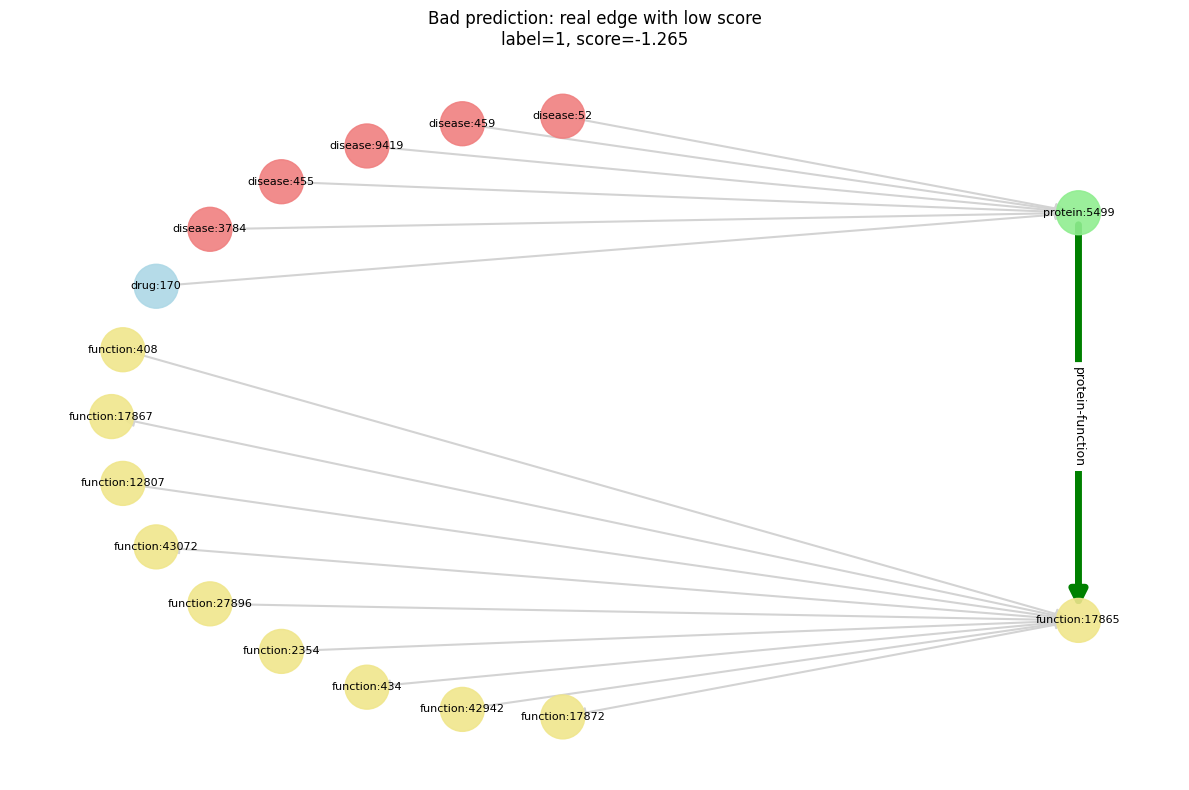

In [118]:
draw_prediction_subgraph(
    bad_positive,
    title="Bad prediction: real edge with low score",
    max_neighbors=15
)

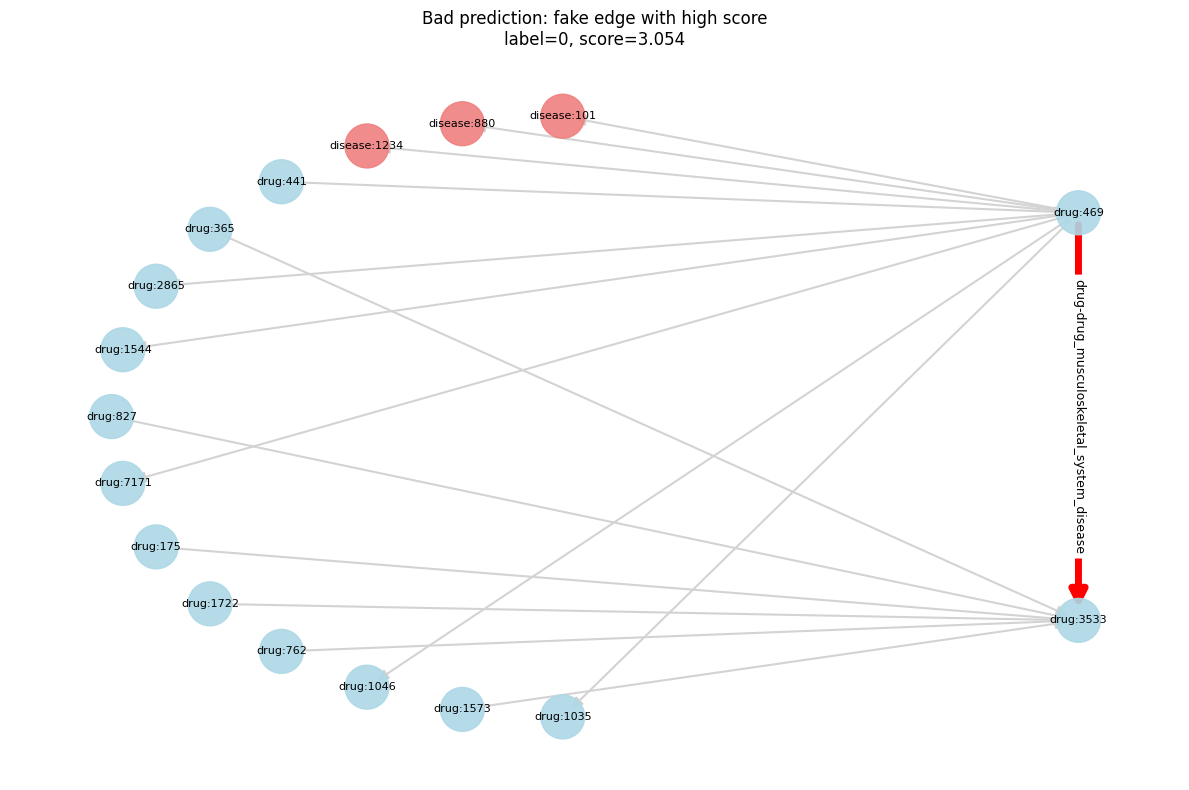

In [119]:
draw_prediction_subgraph(
    bad_negative,
    title="Bad prediction: fake edge with high score",
    max_neighbors=15
)

## Inter-Meta-Path Attention Analysis

Loaded best experiment: large_batch


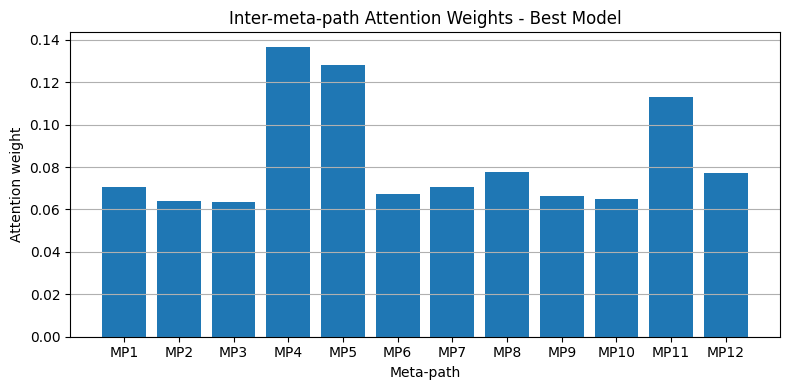

In [112]:
# Load best model weights
embedding_layer.load_state_dict(best_state["embedding_layer"])
intra_attention.load_state_dict(best_state["intra_attention"])
inter_attention.load_state_dict(best_state["inter_attention"])
link_predictor.load_state_dict(best_state["link_predictor"])

embedding_layer.eval()
intra_attention.eval()
inter_attention.eval()
link_predictor.eval()

print("Loaded best experiment:", best_experiment)

# Compute inter-meta-path attention weights for the best model
with torch.no_grad():
    final_emb, inter_weights, metapath_names = encode_metapaths_for_selected_node(
        selected_metapaths,
        max_instances_per_metapath=20
    )

weights = inter_weights.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.bar(range(len(weights)), weights)
plt.xticks(range(len(weights)), [f"MP{i+1}" for i in range(len(weights))])
plt.xlabel("Meta-path")
plt.ylabel("Attention weight")
plt.title("Inter-meta-path Attention Weights - Best Model")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [113]:
for i, name in enumerate(metapath_names):
    pretty_name = name

    for rel_id, rel_name in relation_id_to_name.items():
        pretty_name = pretty_name.replace(
            f"--r{rel_id}-->",
            f"--{rel_name}-->"
        )

    print(f"MP{i+1}: {pretty_name} | weight={weights[i]:.4f}")

MP1: protein --protein-protein_reaction--> protein --protein-protein_reaction--> protein | weight=0.0707
MP2: protein --protein-protein_catalysis--> protein --protein-protein_catalysis--> protein | weight=0.0640
MP3: protein --protein-protein_catalysis--> protein --protein-protein_reaction--> protein | weight=0.0635
MP4: protein --protein-protein_reaction--> protein --protein-protein_catalysis--> protein | weight=0.1367
MP5: protein --protein-protein_binding--> protein --protein-protein_binding--> protein | weight=0.1281
MP6: protein --protein-protein_binding--> protein --protein-protein_reaction--> protein | weight=0.0671
MP7: protein --protein-protein_reaction--> protein --protein-protein_binding--> protein | weight=0.0707
MP8: drug --drug-drug_cardiovascular_system_disease--> drug --drug-sideeffect--> sideeffect | weight=0.0777
MP9: protein --protein-protein_binding--> protein --protein-protein_catalysis--> protein | weight=0.0662
MP10: protein --protein-protein_catalysis--> protein